In [15]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("data/Index_ETF_Data_Clean.csv")

In [17]:
df.head(3)

,Dates,SPY US Equity PX_LAST,SPY US Equity PX_MID,SPY US Equity PX_VOLUME,EZU US Equity PX_LAST,EZU US Equity PX_MID,EZU US Equity PX_VOLUME,EWJ US Equity PX_LAST,EWJ US Equity PX_MID,EWJ US Equity PX_VOLUME,VIX Index PX_LAST,NKYVF Index PX_LAST,V2X Index PX_LAST
0,2012-02-27,106.5620,106.6008,145728833,21.3544,23.7530,258726,30.7449,30.7910,4146708,18.19,100000.00,24.2211
1,2012-02-28,106.8720,106.9194,129355808,21.5568,24.1004,152564,31.2364,31.2671,3915278,17.96,99553.23,23.7173
2,2012-02-29,106.4532,106.2396,185934689,21.2599,22.1640,332041,30.6835,30.6374,5205787,18.43,102086.10,23.9289


In [18]:
df.columns

Index(['Dates', 'SPY US Equity PX_LAST', 'SPY US Equity PX_MID',
       'SPY US Equity PX_VOLUME', 'EZU US Equity PX_LAST',
       'EZU US Equity PX_MID', 'EZU US Equity PX_VOLUME',
       'EWJ US Equity PX_LAST', 'EWJ US Equity PX_MID',
       'EWJ US Equity PX_VOLUME', 'VIX Index PX_LAST', 'NKYVF Index PX_LAST',
       'V2X Index PX_LAST'],
      dtype='object')

In [19]:
# Make a copy so the original DataFrame is not modified
eda_df = df.copy()

# Convert dates and sort chronologically
eda_df["Dates"] = pd.to_datetime(eda_df["Dates"], errors="coerce")
eda_df = eda_df.sort_values("Dates")
eda_df = eda_df.set_index("Dates")

price_cols = [
    "SPY US Equity PX_LAST",
    "EZU US Equity PX_LAST",
    "EWJ US Equity PX_LAST"
]

volume_cols = [
    "SPY US Equity PX_VOLUME",
    "EZU US Equity PX_VOLUME",
    "EWJ US Equity PX_VOLUME"
]

vol_cols = [
    "VIX Index PX_LAST",
    "NKYVF Index PX_LAST",
    "V2X Index PX_LAST"
]

# Ensure Bloomberg data columns are numeric
all_numeric_cols = price_cols + volume_cols + vol_cols

for col in all_numeric_cols:
    eda_df[col] = pd.to_numeric(eda_df[col], errors="coerce")

# Calculate daily returns
returns = eda_df[price_cols].pct_change(fill_method=None)
returns.columns = ["SPY", "EZU", "EWJ"]

# Remove rows where all three returns are missing
returns = returns.dropna(how="all")

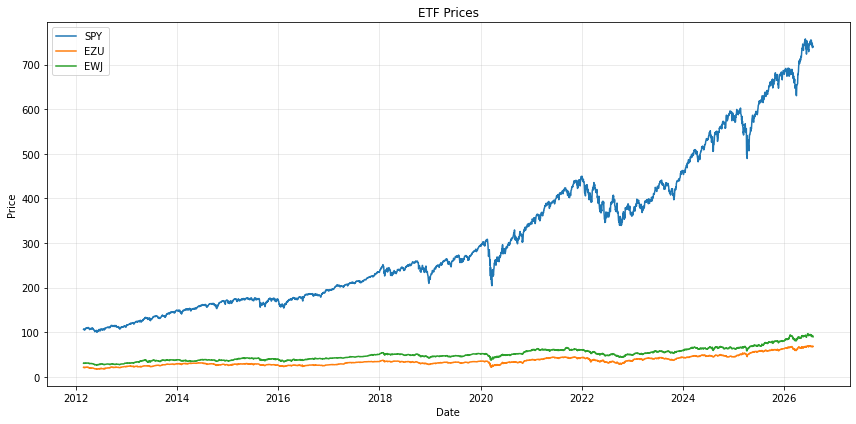

In [20]:
plt.figure(figsize=(12, 6))

x = eda_df.index.to_numpy()

for col in price_cols:
    y = eda_df[col].to_numpy()
    plt.plot(x, y, label=col.split()[0])

plt.title("ETF Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

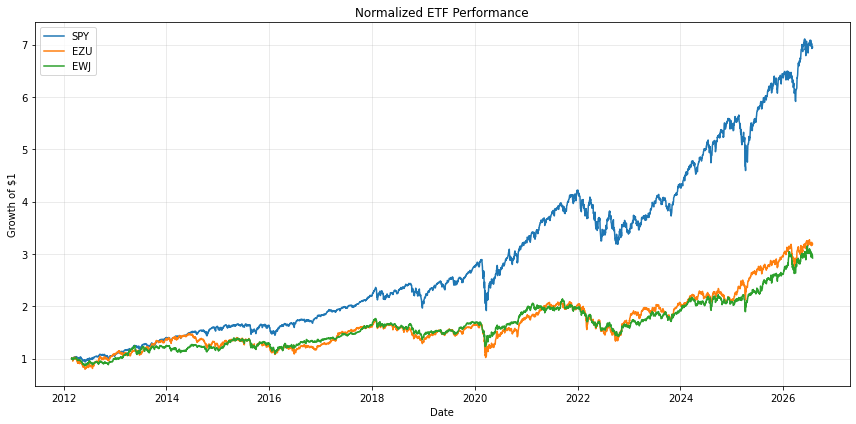

In [21]:
normalized = eda_df[price_cols].copy()

# Normalize each column using its first valid observation
for col in normalized.columns:
    first_valid_value = normalized[col].dropna().iloc[0]
    normalized[col] = normalized[col] / first_valid_value

plt.figure(figsize=(12, 6))

x = normalized.index.to_numpy()

for col in normalized.columns:
    y = normalized[col].to_numpy()
    plt.plot(x, y, label=col.split()[0])

plt.title("Normalized ETF Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

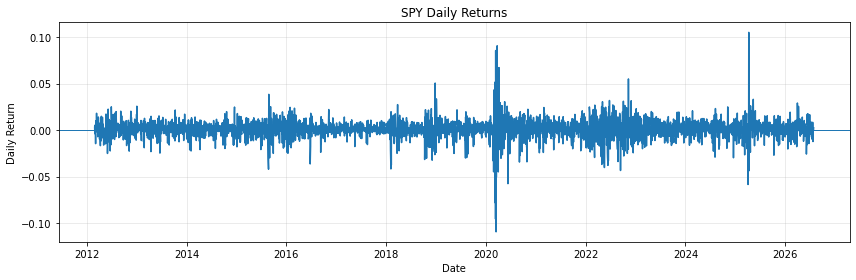

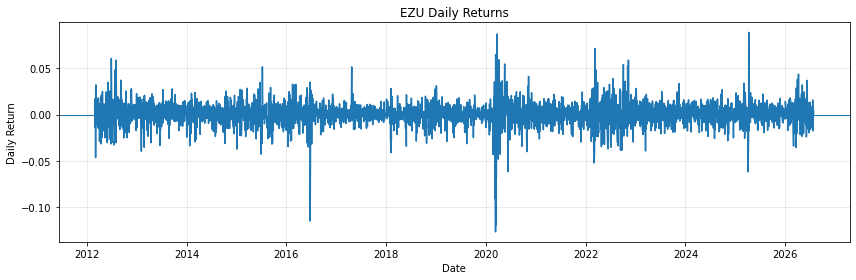

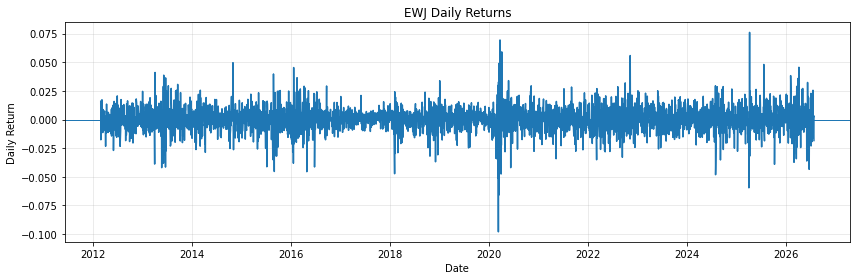

In [22]:
for col in returns.columns:
    plt.figure(figsize=(12, 4))

    plt.plot(
        returns.index.to_numpy(),
        returns[col].to_numpy()
    )

    plt.axhline(0, linewidth=1)
    plt.title(f"{col} Daily Returns")
    plt.xlabel("Date")
    plt.ylabel("Daily Return")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

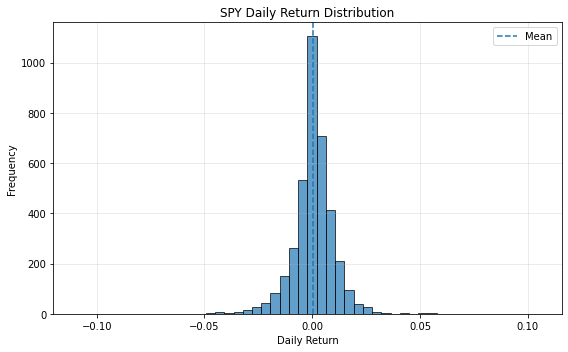

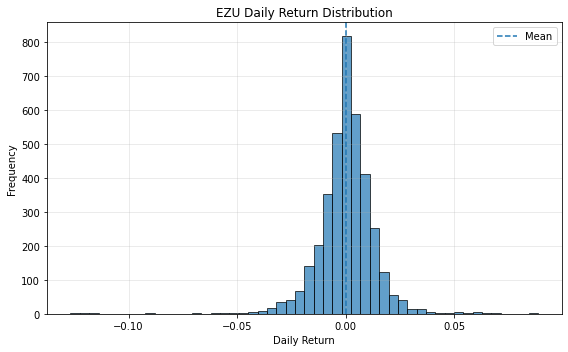

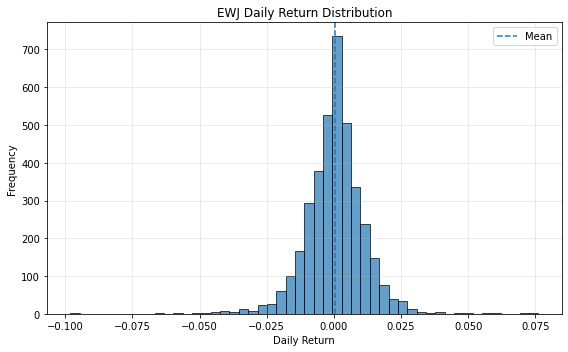

In [23]:
for col in returns.columns:
    plt.figure(figsize=(8, 5))

    clean_returns = returns[col].dropna().to_numpy()

    plt.hist(clean_returns, bins=50, edgecolor="black", alpha=0.7)
    plt.axvline(clean_returns.mean(), linestyle="--", label="Mean")

    plt.title(f"{col} Daily Return Distribution")
    plt.xlabel("Daily Return")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

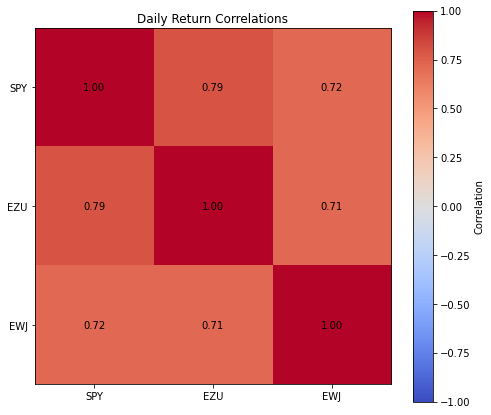

In [24]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(7, 6))

correlation_values = corr.to_numpy()

image = ax.imshow(
    correlation_values,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns)

ax.set_yticks(np.arange(len(corr.index)))
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(
            j,
            i,
            f"{correlation_values[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(image, ax=ax, label="Correlation")
ax.set_title("Daily Return Correlations")

plt.tight_layout()
plt.show()

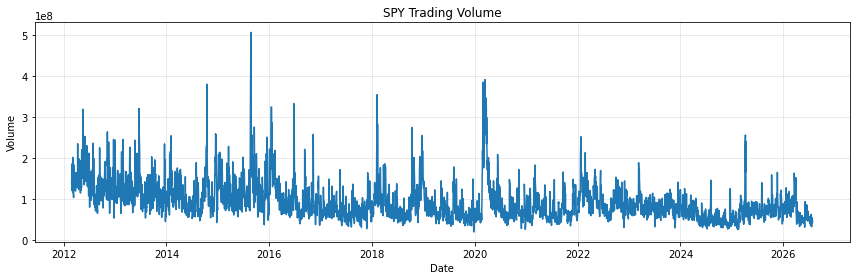

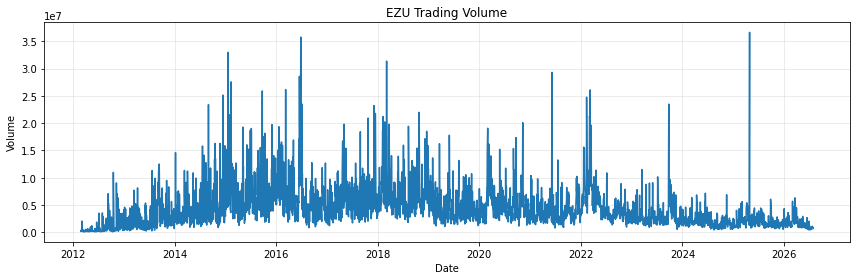

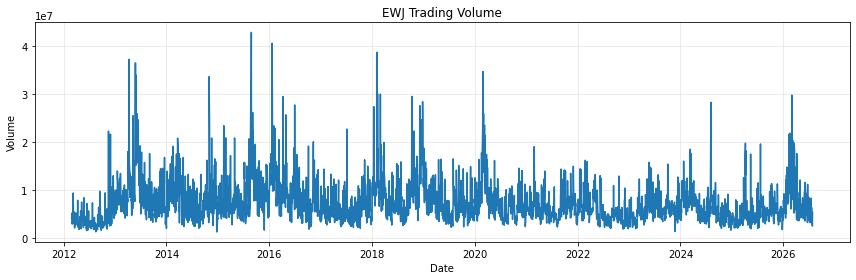

In [25]:
for col in volume_cols:
    plt.figure(figsize=(12, 4))

    plt.plot(
        eda_df.index.to_numpy(),
        eda_df[col].to_numpy()
    )

    plt.title(f"{col.split()[0]} Trading Volume")
    plt.xlabel("Date")
    plt.ylabel("Volume")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

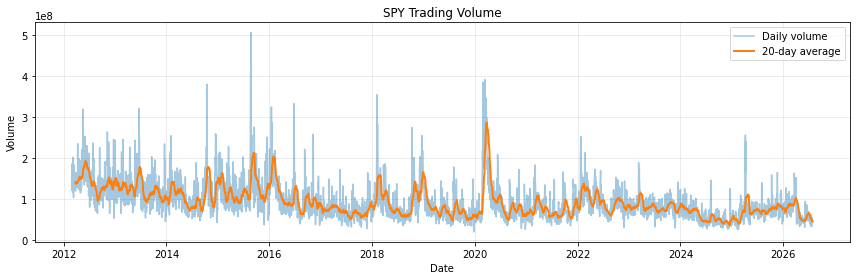

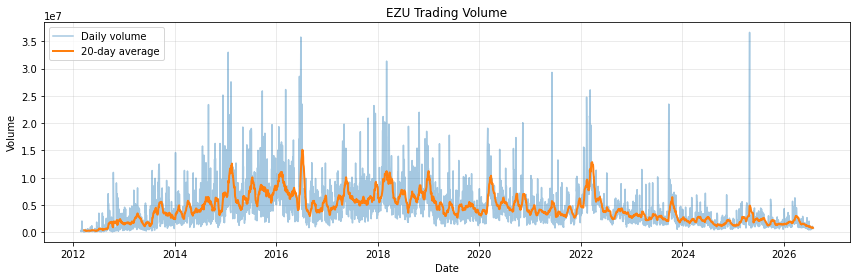

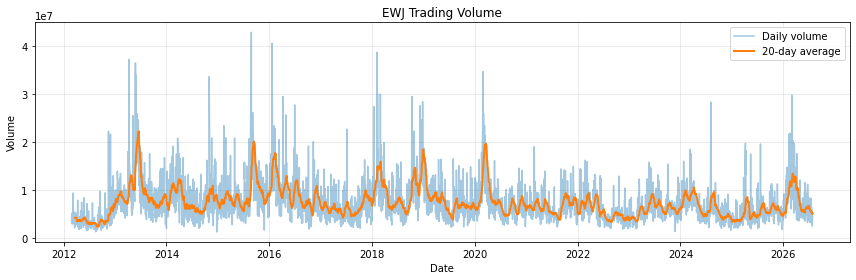

In [26]:
for col in volume_cols:
    volume_ma = eda_df[col].rolling(20).mean()

    plt.figure(figsize=(12, 4))

    plt.plot(
        eda_df.index.to_numpy(),
        eda_df[col].to_numpy(),
        alpha=0.4,
        label="Daily volume"
    )

    plt.plot(
        volume_ma.index.to_numpy(),
        volume_ma.to_numpy(),
        linewidth=2,
        label="20-day average"
    )

    plt.title(f"{col.split()[0]} Trading Volume")
    plt.xlabel("Date")
    plt.ylabel("Volume")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

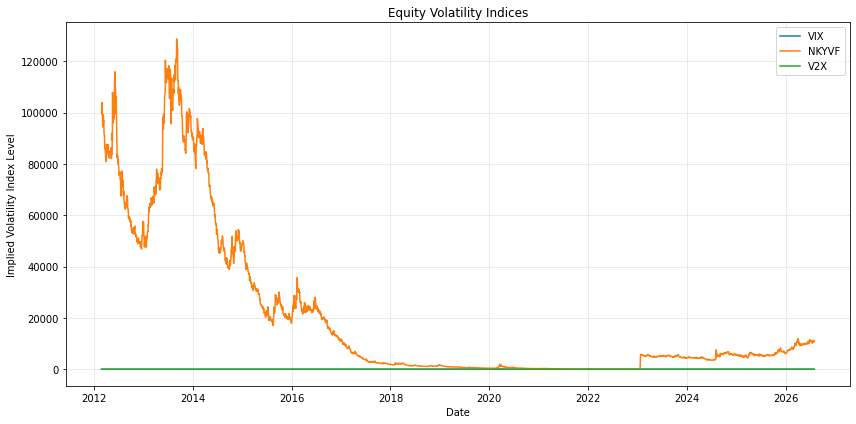

In [27]:
plt.figure(figsize=(12, 6))

x = eda_df.index.to_numpy()

for col in vol_cols:
    plt.plot(
        x,
        eda_df[col].to_numpy(),
        label=col.split()[0]
    )

plt.title("Equity Volatility Indices")
plt.xlabel("Date")
plt.ylabel("Implied Volatility Index Level")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

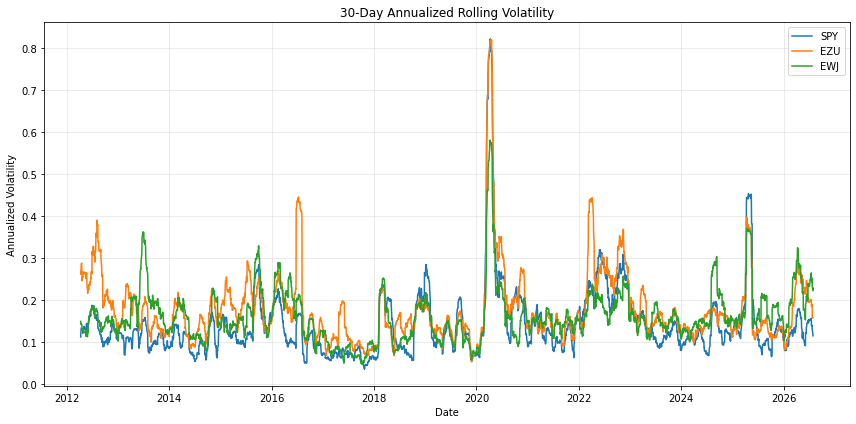

In [28]:
rolling_volatility = returns.rolling(30).std() * np.sqrt(252)

plt.figure(figsize=(12, 6))

for col in rolling_volatility.columns:
    plt.plot(
        rolling_volatility.index.to_numpy(),
        rolling_volatility[col].to_numpy(),
        label=col
    )

plt.title("30-Day Annualized Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

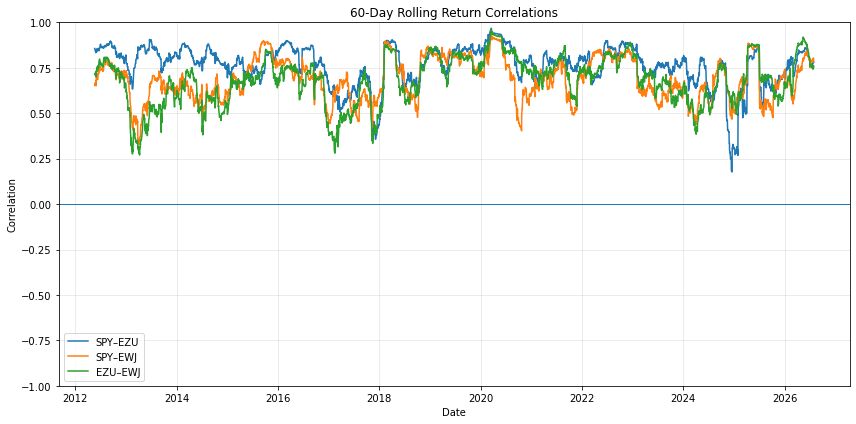

In [30]:
rolling_correlations = pd.DataFrame(index=returns.index)

rolling_correlations["SPY–EZU"] = (
    returns["SPY"].rolling(60).corr(returns["EZU"])
)

rolling_correlations["SPY–EWJ"] = (
    returns["SPY"].rolling(60).corr(returns["EWJ"])
)

rolling_correlations["EZU–EWJ"] = (
    returns["EZU"].rolling(60).corr(returns["EWJ"])
)

plt.figure(figsize=(12, 6))

for col in rolling_correlations.columns:
    plt.plot(
        rolling_correlations.index.to_numpy(),
        rolling_correlations[col].to_numpy(),
        label=col
    )

plt.axhline(0, linewidth=1)
plt.title("60-Day Rolling Return Correlations")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.ylim(-1, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

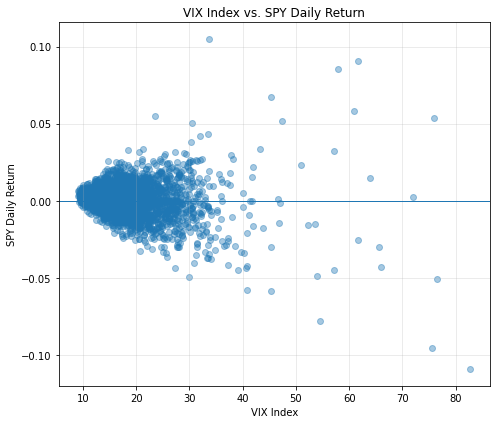

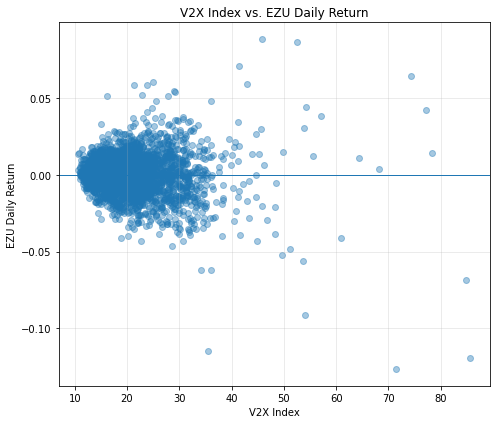

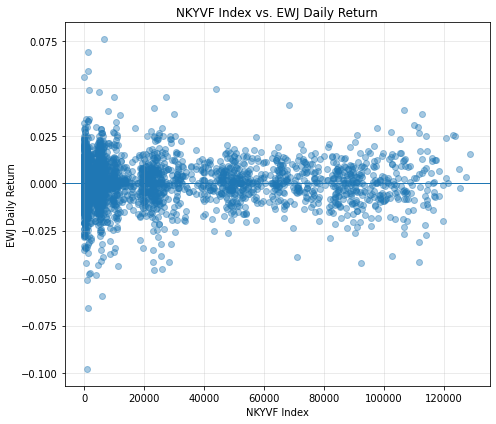

In [31]:
region_mapping = {
    "SPY": "VIX Index PX_LAST",
    "EZU": "V2X Index PX_LAST",
    "EWJ": "NKYVF Index PX_LAST"
}

for etf, vol_index in region_mapping.items():
    relationship_data = pd.concat(
        [
            returns[etf],
            eda_df[vol_index]
        ],
        axis=1
    ).dropna()

    relationship_data.columns = ["ETF_Return", "Volatility_Index"]

    plt.figure(figsize=(7, 6))

    plt.scatter(
        relationship_data["Volatility_Index"].to_numpy(),
        relationship_data["ETF_Return"].to_numpy(),
        alpha=0.4
    )

    plt.axhline(0, linewidth=1)

    plt.xlabel(vol_index.replace(" PX_LAST", ""))
    plt.ylabel(f"{etf} Daily Return")
    plt.title(
        f"{vol_index.replace(' PX_LAST', '')} vs. "
        f"{etf} Daily Return"
    )

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

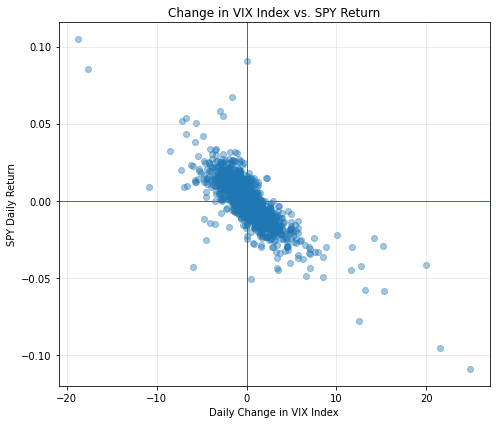

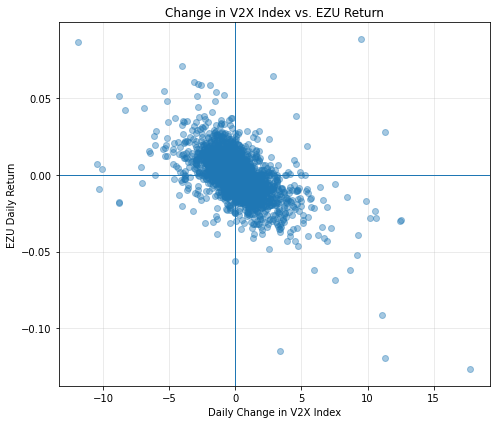

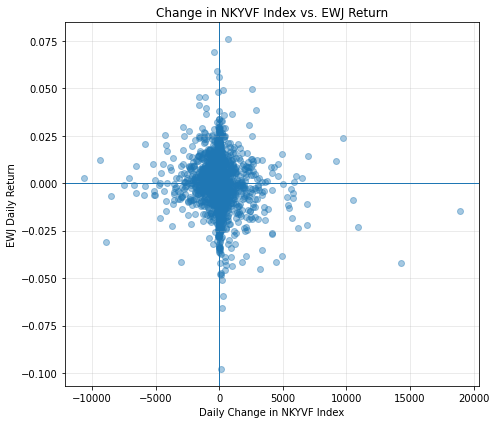

In [32]:
volatility_changes = eda_df[vol_cols].diff()

region_mapping = {
    "SPY": "VIX Index PX_LAST",
    "EZU": "V2X Index PX_LAST",
    "EWJ": "NKYVF Index PX_LAST"
}

for etf, vol_index in region_mapping.items():
    relationship_data = pd.concat(
        [
            returns[etf],
            volatility_changes[vol_index]
        ],
        axis=1
    ).dropna()

    relationship_data.columns = ["ETF_Return", "Volatility_Change"]

    plt.figure(figsize=(7, 6))

    plt.scatter(
        relationship_data["Volatility_Change"].to_numpy(),
        relationship_data["ETF_Return"].to_numpy(),
        alpha=0.4
    )

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)

    plt.xlabel(f"Daily Change in {vol_index.replace(' PX_LAST', '')}")
    plt.ylabel(f"{etf} Daily Return")
    plt.title(
        f"Change in {vol_index.replace(' PX_LAST', '')} "
        f"vs. {etf} Return"
    )

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

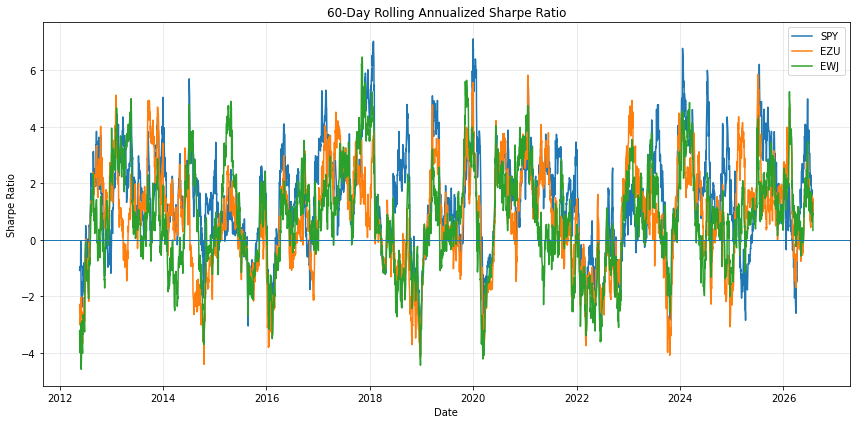

In [33]:
rolling_mean = returns.rolling(60).mean()
rolling_std = returns.rolling(60).std()

rolling_sharpe = (
    rolling_mean.div(rolling_std) * np.sqrt(252)
)

# Avoid plotting infinite values caused by zero rolling volatility
rolling_sharpe = rolling_sharpe.replace(
    [np.inf, -np.inf],
    np.nan
)

plt.figure(figsize=(12, 6))

for col in rolling_sharpe.columns:
    plt.plot(
        rolling_sharpe.index.to_numpy(),
        rolling_sharpe[col].to_numpy(),
        label=col
    )

plt.axhline(0, linewidth=1)
plt.title("60-Day Rolling Annualized Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

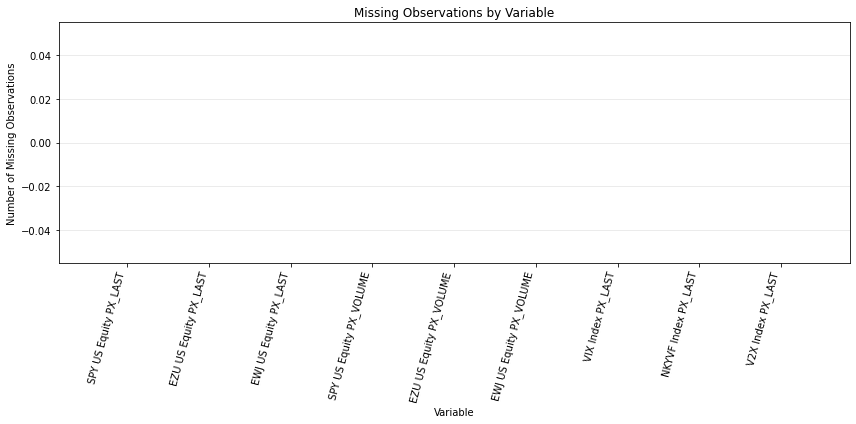

In [34]:
missing_counts = eda_df[all_numeric_cols].isna().sum()
missing_counts = missing_counts.sort_values(ascending=False)

plt.figure(figsize=(12, 6))

plt.bar(
    np.arange(len(missing_counts)),
    missing_counts.to_numpy()
)

plt.xticks(
    np.arange(len(missing_counts)),
    missing_counts.index,
    rotation=75,
    ha="right"
)

plt.title("Missing Observations by Variable")
plt.xlabel("Variable")
plt.ylabel("Number of Missing Observations")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()